# Using GAN to generate images
The next natural step after the tabular is generating images using a GAN. For this, there are 
`ImageGenerator` and `ImageDiscriminator` classes that can plug in to a GANProcess (or WGANPprocess) and
work with multi-dimensional data like image data. This notebook looks at using the MNIST data set to create synthetic images.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from synthetic_generation.gan.models import ImageGenerator, ImageDiscriminator
from synthetic_generation.gan.process import GANProcess



/home/ec2-user/miniconda3/envs/GAN/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load MNIST, normalize to [-1, 1] to match tanh output
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

In [ ]:
class ConditionalDataset(Dataset):
    """
    class used to create a Dataset where we replace the labels for
    the conditional with a one hot encoded version
    """
    def __init__(self, mnist_dataset, num_classes=10):
        self.dataset = mnist_dataset
        self.num_classes = num_classes
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        one_hot = torch.zeros(self.num_classes)
        one_hot[label] = 1.0
        return image, one_hot

In [ ]:
# turn the train dataset to a conditional one and load into a dataloader
conditional_dataset = ConditionalDataset(train_dataset)
dataloader = DataLoader(conditional_dataset, batch_size=128, shuffle=True)

In [ ]:
# train an ImageGenerator/ImageDiscriminator pair on the MNIST data
G = ImageGenerator(noise_dim = 100, output_dim = (1,28,28), conv_in_channels=256, num_conv_layers=2, conditional_dim = 10)
D = ImageDiscriminator(feature_dim = (1, 28, 28), conv_out_channels=64, num_conv_layers=2, conditional_dim=10, use_bn=True)
process = GANProcess(G=G, D=D)
history = process.train(
    X=dataloader,
)

GAN training: 100%|██████████| 200/200 [1:09:53<00:00, 20.97s/it, D=0.4612, G=3.4205]


In [1]:
#### How did it do? We look at a sample digit from each class

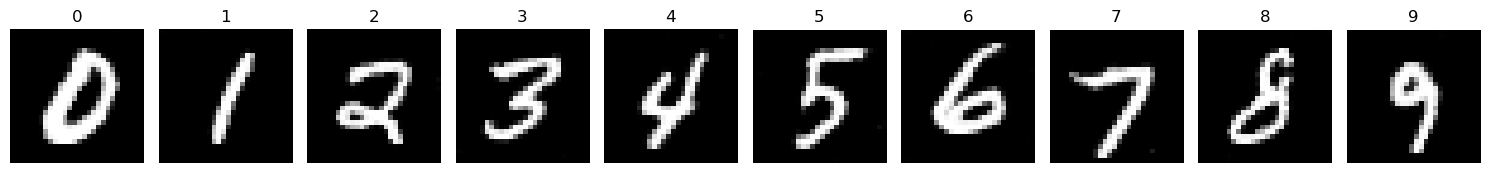

In [6]:



# generate one sample per digit class
samples = []
for digit in range(10):
    c = torch.zeros(1, 10)
    c[0, digit] = 1.0
    sample = process.generate_samples(1, c=c)
    samples.append(sample)

# plot in a row
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, (ax, sample) in enumerate(zip(axes, samples)):
    ax.imshow(sample.squeeze(), cmap='gray')
    ax.set_title(str(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

## Conclusion
This basic architecture works well enough to produce digits after training on the MNIST dataset